# XGBoost Adaptive Resource Allocation Model
### Bachelor Thesis — Hybrid DE-WOA Cluster Manager

**Goal:** Predict optimal fitness weights `(w_cpu, w_ram, w_io, w_energy)` and dynamic thresholds  
`(thresh_cpu, thresh_ram, thresh_http)` from live cluster metrics, with **incremental learning**  
so the model adapts every 5 minutes as new data arrives.

---

### Architecture Overview
```
InfluxDB metrics  ──►  Feature Engineering  ──►  7 XGBRegressors  ──►  Predicted weights & thresholds
                                                       │
                                              Incremental Update
                                           (every 5 min, +20 trees)
```

### Why 7 separate models (not one MultiOutput)?
- XGBoost's `xgb_model=` parameter enables **true incremental learning** (adds new trees on top)
- `MultiOutputRegressor` wraps sklearn's interface and breaks the `xgb_model=` warm-start
- Each target has a different scale and noise profile — separate models give better R²
- Each `.ubj` file is tiny (~500KB) and loads in milliseconds in `main.py`

## 1. Imports & Configuration

In [ ]:
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# ── Constants matching the simulation ──────────────────────────────────────────
SCRAPE_INTERVAL = 15          # seconds between Prometheus scrapes
MODELS_DIR      = './models'  # where .ubj model files are saved
DATA_DIR        = './data'
os.makedirs(MODELS_DIR, exist_ok=True)

# ── All 7 prediction targets ───────────────────────────────────────────────────
TARGET_WEIGHTS = ['w_cpu', 'w_ram', 'w_io', 'w_energy']
TARGET_THRESH  = ['thresh_cpu', 'thresh_ram', 'thresh_http']
ALL_TARGETS    = TARGET_WEIGHTS + TARGET_THRESH

print(f"XGBoost version : {xgb.__version__}")
print(f"Targets to predict: {ALL_TARGETS}")

XGBoost version : 3.2.0
Targets to predict: ['w_cpu', 'w_ram', 'w_io', 'w_energy', 'thresh_cpu', 'thresh_ram', 'thresh_http']


## 2. Load Raw Data

In [ ]:
df_metrics = pd.read_csv(f'{DATA_DIR}/1_influxdb_raw_metrics.csv')
df_logs    = pd.read_csv(f'{DATA_DIR}/2_cluster_manager_logs.csv')

print(f"Metrics shape : {df_metrics.shape}")
print(f"Logs shape    : {df_logs.shape}")
print(f"\nUnique instances : {df_metrics['instance'].nunique()}")
print(f"Time range       : {df_metrics['_time'].min()}  →  {df_metrics['_time'].max()}")

df_metrics.head(3)

Metrics shape : (812621, 17)
Logs shape    : (1158067, 14)

Unique instances : 1214
Time range       : 2026-04-15T03:18:21Z  →  2026-04-15T08:52:51Z


,_time,instance,vm_name,vlan,pm_ip,up,scrape_duration_seconds,node_vmstat_oom_kill,node_cpu_seconds_total_idle,node_memory_MemAvailable_bytes,node_memory_MemTotal_bytes,node_disk_io_time_seconds_total,http_requests_total_all,http_requests_total_5xx,node_network_receive_packets_total,node_network_receive_drop_total,scaph_vm_power_microwatts
0,2026-04-15T03:18:21Z,10.30.30.10:9100,monitoring-stack-1,vlan-monitoring,172.25.5.12,1.0,0.130,0.0,258.05,3.010788e+09,4.294967e+09,63.50,4417.0,3.0,42216.0,5.0,52973688.0
1,2026-04-15T03:18:21Z,10.30.30.11:9100,influxdb-2,vlan-monitoring,172.25.5.16,1.0,0.097,0.0,400.25,3.294773e+09,4.294967e+09,91.07,1869.0,10.0,21959.0,3.0,53401837.0
2,2026-04-15T03:18:21Z,10.30.30.12:9100,snmp-exporter-3,vlan-monitoring,172.25.5.12,1.0,0.198,0.0,340.24,3.787084e+09,4.294967e+09,49.63,4147.0,7.0,53648.0,2.0,52923749.0


In [ ]:
df_logs.head(3)

,_time,instance,vm_name,incident_type,w_cpu,w_ram,w_io,w_energy,thresh_cpu,thresh_ram,thresh_http,action_vertical_cpu,action_vertical_ram,action_horizontal
0,2026-04-15T03:18:21Z,10.30.30.10:9100,monitoring-stack-1,NaN,0.1500,0.2765,0.0838,0.4898,76.8,82.0,2.0,0.0,0.0,0.0
1,2026-04-15T03:18:21Z,10.30.30.11:9100,influxdb-2,NaN,0.1757,0.2443,0.0198,0.5602,76.6,82.7,2.0,0.0,0.0,0.0
2,2026-04-15T03:18:21Z,10.30.30.12:9100,snmp-exporter-3,NaN,0.1904,0.1394,0.0466,0.6237,76.8,83.8,2.0,0.0,0.0,0.0


## 3. Feature Engineering

The raw CSV contains **cumulative counters** (e.g. `node_cpu_seconds_total_idle` keeps growing).  
XGBoost needs **instantaneous rates** — we compute per-instance deltas between consecutive scrapes.

| Raw Column | Derived Feature | Formula |
|---|---|---|
| `node_cpu_seconds_total_idle` | `cpu_busy_pct` | `(1 - Δidle / scrape_interval) * 100` |
| `node_memory_MemAvailable_bytes` | `ram_usage_pct` | `(1 - avail/total) * 100` |
| `node_disk_io_time_seconds_total` | `io_util_pct` | `Δio_time / scrape_interval * 100` |
| `http_requests_total_5xx` / `all` | `http_5xx_rate` | `Δ5xx / Δall` |
| `node_network_receive_drop_total` | `net_drop_rate` | `Δdrops / Δpackets` |
| `scaph_vm_power_microwatts` | `power_watts` | `microwatts / 1e6` |

In [ ]:
# ── Sort so that per-instance diff() is chronologically correct ────────────────
df = df_metrics.sort_values(['instance', '_time']).reset_index(drop=True)

# ── 1. RAM usage % (no delta needed — it's an instant gauge) ──────────────────
df['ram_usage_pct'] = (
    1 - df['node_memory_MemAvailable_bytes'] / df['node_memory_MemTotal_bytes']
) * 100

# ── 2. CPU busy %  (diff of cumulative idle counter per instance) ──────────────
df['_cpu_idle_delta'] = df.groupby('instance')['node_cpu_seconds_total_idle'].diff()
# First scrape per instance has NaN delta → fill with 0 (no change known yet)
df['_cpu_idle_delta'] = df['_cpu_idle_delta'].fillna(0).clip(lower=0)
# idle_rate: fraction of the interval spent idle  (capped to [0,1])
idle_rate = (df['_cpu_idle_delta'] / SCRAPE_INTERVAL).clip(0, 1)
df['cpu_busy_pct'] = (1 - idle_rate) * 100

# ── 3. Disk IO utilisation % ──────────────────────────────────────────────────
df['_io_delta'] = df.groupby('instance')['node_disk_io_time_seconds_total'].diff().fillna(0).clip(lower=0)
df['io_util_pct'] = (df['_io_delta'] / SCRAPE_INTERVAL * 100).clip(0, 100)

# ── 4. HTTP 5xx error rate ────────────────────────────────────────────────────
df['_http_all_delta']  = df.groupby('instance')['http_requests_total_all'].diff().fillna(0).clip(lower=1)
df['_http_5xx_delta']  = df.groupby('instance')['http_requests_total_5xx'].diff().fillna(0).clip(lower=0)
df['http_5xx_rate']    = (df['_http_5xx_delta'] / df['_http_all_delta']).clip(0, 1)

# ── 5. Network packet drop rate ───────────────────────────────────────────────
df['_net_pkt_delta']  = df.groupby('instance')['node_network_receive_packets_total'].diff().fillna(0).clip(lower=1)
df['_net_drop_delta'] = df.groupby('instance')['node_network_receive_drop_total'].diff().fillna(0).clip(lower=0)
df['net_drop_rate']   = (df['_net_drop_delta'] / df['_net_pkt_delta']).clip(0, 1)

# ── 6. Power in watts (human-readable scale) ─────────────────────────────────
df['power_watts'] = df['scaph_vm_power_microwatts'] / 1_000_000

# ── 7. Role one-hot flags (derived from vm_name) ─────────────────────────────
df['is_worker']  = df['vm_name'].str.contains('worker',              case=False).fillna(False).astype(int)
df['is_master']  = df['vm_name'].str.contains('master',              case=False).fillna(False).astype(int)
df['is_monitor'] = df['vm_name'].str.contains('monitoring|influx|snmp', case=False, regex=True).fillna(False).astype(int)

# ── 8. VLAN ordinal encoding ──────────────────────────────────────────────────
vlan_encoder = LabelEncoder()
df['vlan_enc'] = vlan_encoder.fit_transform(df['vlan'])
print("VLAN encoding:", dict(zip(vlan_encoder.classes_, vlan_encoder.transform(vlan_encoder.classes_))))

# ── 9. Incident flags (from influxdb columns) ─────────────────────────────────
# scrape_duration_seconds > 2 → High_Latency; up == 0 → VM_Unreachable
# These are already present in the metrics CSV and carry rich predictive signal

# ── Drop intermediate helper columns ──────────────────────────────────────────
helper_cols = ['_cpu_idle_delta', '_io_delta', '_http_all_delta', '_http_5xx_delta', '_net_pkt_delta', '_net_drop_delta']
df.drop(columns=helper_cols, inplace=True)

print(f"\nFeature engineering complete. Shape: {df.shape}")
df[['instance','cpu_busy_pct','ram_usage_pct','io_util_pct','http_5xx_rate','net_drop_rate','power_watts']].describe()

VLAN encoding: {'vlan-1-app': np.int64(0), 'vlan-2-app': np.int64(1), 'vlan-monitoring': np.int64(2), 'wan': np.int64(3), nan: np.int64(4)}

Feature engineering complete. Shape: (812621, 27)


,cpu_busy_pct,ram_usage_pct,io_util_pct,http_5xx_rate,net_drop_rate,power_watts
count,812621.000000,812620.000000,812621.000000,812621.000000,812621.000000,812620.000000
mean,95.686376,80.073561,5.415479,0.020731,0.011267,115.871845
std,13.916678,12.876684,2.674229,0.013785,0.006878,13.958232
min,1.000000,5.000000,0.000000,0.000000,0.000000,0.000000
25%,97.466667,73.231868,3.133333,0.008696,0.005344,117.880321
50%,100.000000,81.190029,5.333333,0.020316,0.011070,120.000000
75%,100.000000,89.361442,7.666667,0.032258,0.017014,120.000000
max,100.000000,97.999978,10.000000,0.049892,0.024982,120.000000


## 4. Merge Metrics with Manager Logs (targets)

In [ ]:
# Only keep rows that appear in both datasets (inner join on time+instance+vm_name)
# This drops monitoring-only rows and the first scrape per instance (no delta yet)
df_merged = pd.merge(
    df, df_logs,
    on=['_time', 'instance', 'vm_name'],
    how='inner'
)

print(f"Merged shape: {df_merged.shape}")
print(f"Columns     : {df_merged.columns.tolist()}")

Merged shape: (812620, 38)
Columns     : ['_time', 'instance', 'vm_name', 'vlan', 'pm_ip', 'up', 'scrape_duration_seconds', 'node_vmstat_oom_kill', 'node_cpu_seconds_total_idle', 'node_memory_MemAvailable_bytes', 'node_memory_MemTotal_bytes', 'node_disk_io_time_seconds_total', 'http_requests_total_all', 'http_requests_total_5xx', 'node_network_receive_packets_total', 'node_network_receive_drop_total', 'scaph_vm_power_microwatts', 'ram_usage_pct', 'cpu_busy_pct', 'io_util_pct', 'http_5xx_rate', 'net_drop_rate', 'power_watts', 'is_worker', 'is_master', 'is_monitor', 'vlan_enc', 'incident_type', 'w_cpu', 'w_ram', 'w_io', 'w_energy', 'thresh_cpu', 'thresh_ram', 'thresh_http', 'action_vertical_cpu', 'action_vertical_ram', 'action_horizontal']


## 5. Define X (Features) and Y (Targets)

### What goes in X and why

| Feature | Why it matters |
|---|---|
| `up` | VM reachability — unreachable nodes should get zero weight |
| `scrape_duration_seconds` | High latency → CPU bottleneck indicator |
| `cpu_busy_pct` | Primary driver of `w_cpu` and `thresh_cpu` |
| `ram_usage_pct` | Primary driver of `w_ram` and `thresh_ram` |
| `io_util_pct` | Primary driver of `w_io` |
| `http_5xx_rate` | Error rate — drives `thresh_http` |
| `net_drop_rate` | Network congestion signal |
| `power_watts` | Primary driver of `w_energy` |
| `is_worker / is_master / is_monitor` | Role context — workers tolerate higher CPU |
| `vlan_enc` | Network zone — affects latency and packet policy |

### What does NOT go in X
- `_time` — timestamp (not a feature, causes data leakage)
- `instance` — IP string (identifier, not a metric)
- `vm_name` — string identifier
- `pm_ip` — physical host IP (string identifier)
- Raw cumulative counters — replaced by derived rate features above
- `incident_type` from logs — this is a result of conditions, not a predictor of weights

In [ ]:
FEATURE_COLS = [
    'up',
    'scrape_duration_seconds',
    'cpu_busy_pct',
    'ram_usage_pct',
    'io_util_pct',
    'http_5xx_rate',
    'net_drop_rate',
    'power_watts',
    'is_worker',
    'is_master',
    'is_monitor',
    'vlan_enc',
]

# Keep only rows where all features AND all targets are non-null
df_model = df_merged[FEATURE_COLS + ALL_TARGETS].dropna()

X = df_model[FEATURE_COLS]
y = df_model[ALL_TARGETS]

print(f"Final dataset: {X.shape[0]} samples × {X.shape[1]} features")
print(f"Targets      : {ALL_TARGETS}")
print(f"\nFeature stats:")
X.describe().round(3)

Final dataset: 812620 samples × 12 features
Targets      : ['w_cpu', 'w_ram', 'w_io', 'w_energy', 'thresh_cpu', 'thresh_ram', 'thresh_http']

Feature stats:


,up,scrape_duration_seconds,cpu_busy_pct,ram_usage_pct,io_util_pct,http_5xx_rate,net_drop_rate,power_watts,is_worker,is_master,is_monitor,vlan_enc
count,812620.000,812620.000,812620.000,812620.000,812620.000,812620.000,812620.000,812620.000,812620.000,812620.000,812620.000,812620.000
mean,0.995,2.899,95.686,80.074,5.415,0.021,0.011,115.872,0.992,0.002,0.005,0.540
std,0.069,1.237,13.917,12.877,2.674,0.014,0.007,13.958,0.090,0.041,0.070,0.518
min,0.000,0.050,1.000,5.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,1.000,2.439,97.467,73.232,3.133,0.009,0.005,117.880,1.000,0.000,0.000,0.000
50%,1.000,3.127,100.000,81.190,5.333,0.020,0.011,120.000,1.000,0.000,0.000,1.000
75%,1.000,3.813,100.000,89.361,7.667,0.032,0.017,120.000,1.000,0.000,0.000,1.000
max,1.000,4.500,100.000,98.000,10.000,0.050,0.025,120.000,1.000,1.000,1.000,3.000


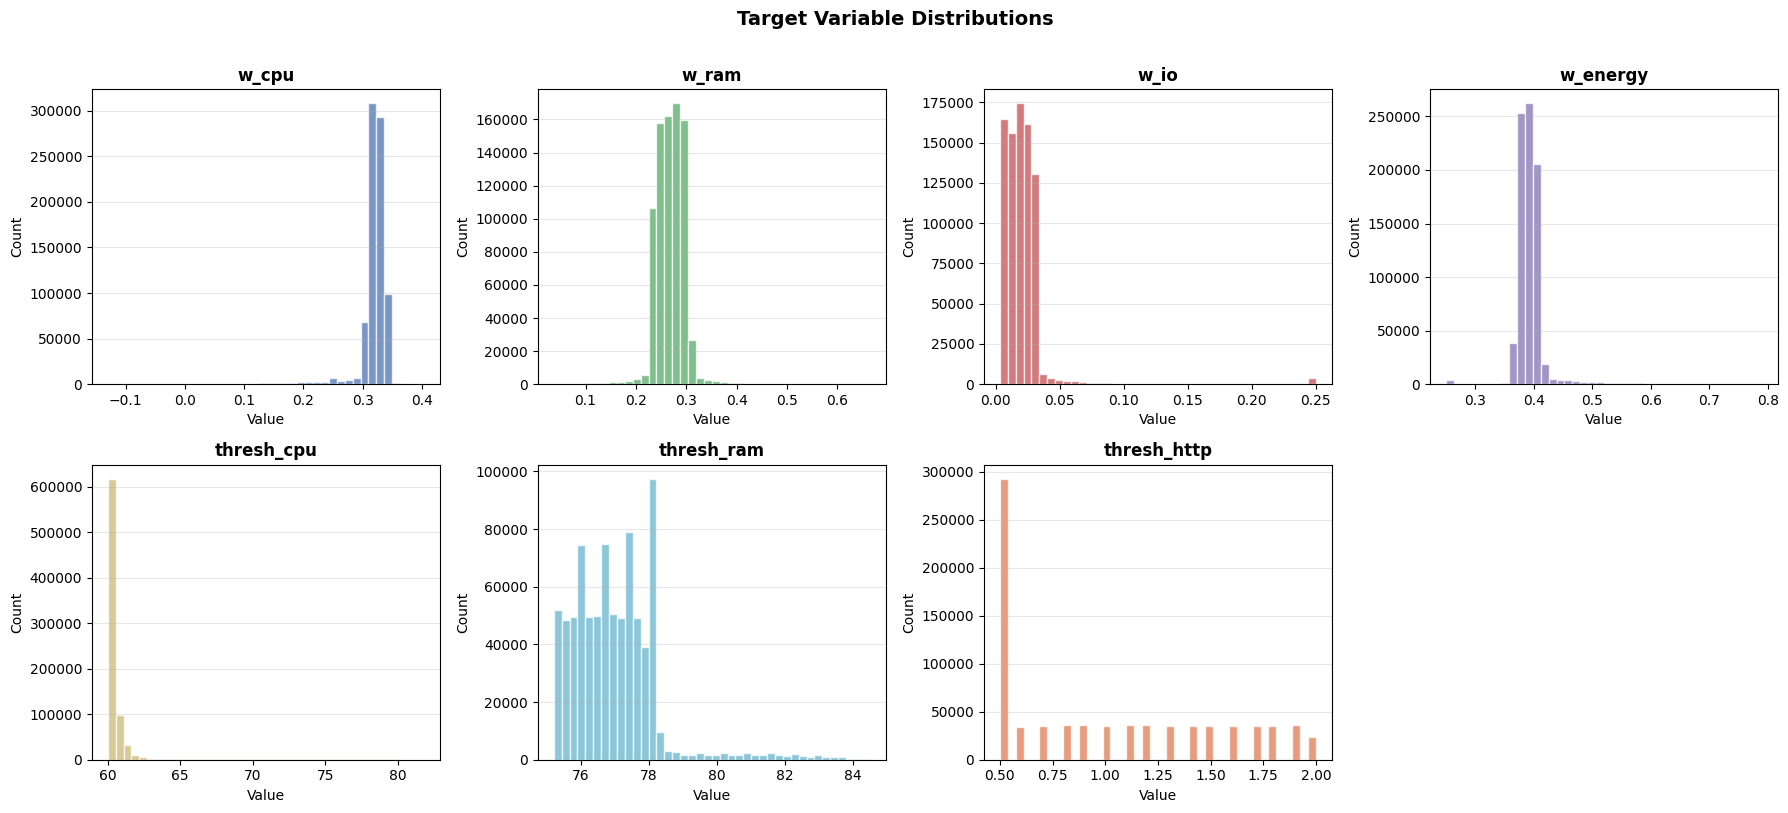

In [ ]:
# Quick look at target distributions
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

colors = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974','#64B5CD','#E07B54']
for i, (target, color) in enumerate(zip(ALL_TARGETS, colors)):
    axes[i].hist(y[target], bins=40, color=color, alpha=0.75, edgecolor='white')
    axes[i].set_title(target, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].grid(axis='y', alpha=0.3)

axes[-1].set_visible(False)  # hide extra subplot
plt.suptitle('Target Variable Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./models/target_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Train/Test Split

> ⚠️ **Important**: `stratify=` is **only for classification** (it balances class labels).  
> For multi-output **regression**, use a plain `shuffle=True` split.

In [ ]:
# 80% train / 20% test — NO stratify (this is regression, not classification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True       # ← shuffle=True is enough for regression
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Test : {X_test.shape[0]} samples")

Train: 650096 samples
Test : 162524 samples


## 7. Train One XGBRegressor per Target

Each model is saved as `models/<target>.ubj` — the native XGBoost binary format.  
These files are loaded by `main.py` at startup and reloaded after each incremental update.

In [ ]:
XGB_PARAMS = dict(
    n_estimators    = 300,
    max_depth       = 6,
    learning_rate   = 0.05,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    min_child_weight= 3,
    tree_method     = 'hist',         # fast histogram-based splits
    objective       = 'reg:squarederror',
    random_state    = 42,
    early_stopping_rounds = 30,       # stop if no improvement for 30 rounds
    eval_metric     = 'mae',
)

models = {}

for target in ALL_TARGETS:
    model = xgb.XGBRegressor(**XGB_PARAMS)
    model.fit(
        X_train, y_train[target],
        eval_set=[(X_test, y_test[target])],
        verbose=False,
    )
    models[target] = model
    model.save_model(f'{MODELS_DIR}/{target}.ubj')
    best = model.best_iteration
    print(f"  [{target:15s}]  best_iteration={best}  "
          f"MAE_train={mean_absolute_error(y_train[target], model.predict(X_train)):.4f}  "
          f"MAE_test={mean_absolute_error(y_test[target], model.predict(X_test)):.4f}")

print(f"\n✓  7 models saved to '{MODELS_DIR}/'")

  [w_cpu          ]  best_iteration=298  MAE_train=0.0003  MAE_test=0.0003
  [w_ram          ]  best_iteration=299  MAE_train=0.0005  MAE_test=0.0006
  [w_io           ]  best_iteration=299  MAE_train=0.0001  MAE_test=0.0001
  [w_energy       ]  best_iteration=298  MAE_train=0.0003  MAE_test=0.0004
  [thresh_cpu     ]  best_iteration=299  MAE_train=0.0063  MAE_test=0.0065
  [thresh_ram     ]  best_iteration=299  MAE_train=0.0103  MAE_test=0.0105
  [thresh_http    ]  best_iteration=299  MAE_train=0.0447  MAE_test=0.0453

✓  7 models saved to './models/'


## 8. Evaluation

In [ ]:
print(f"{'Target':15s}  {'MAE':>8s}  {'R²':>7s}")
print("-" * 35)
results = {}
for target in ALL_TARGETS:
    preds = models[target].predict(X_test)
    mae   = mean_absolute_error(y_test[target], preds)
    r2    = r2_score(y_test[target], preds)
    results[target] = {'mae': mae, 'r2': r2}
    quality = '✓' if r2 > 0.85 else ('~' if r2 > 0.6 else '✗')
    print(f"{target:15s}  {mae:8.4f}  {r2:7.4f}  {quality}")

Target                MAE       R²
-----------------------------------
w_cpu              0.0003   0.9971  ✓
w_ram              0.0006   0.9946  ✓
w_io               0.0001   0.9967  ✓
w_energy           0.0004   0.9951  ✓
thresh_cpu         0.0065   0.9999  ✓
thresh_ram         0.0105   0.9993  ✓
thresh_http        0.0453   0.9782  ✓


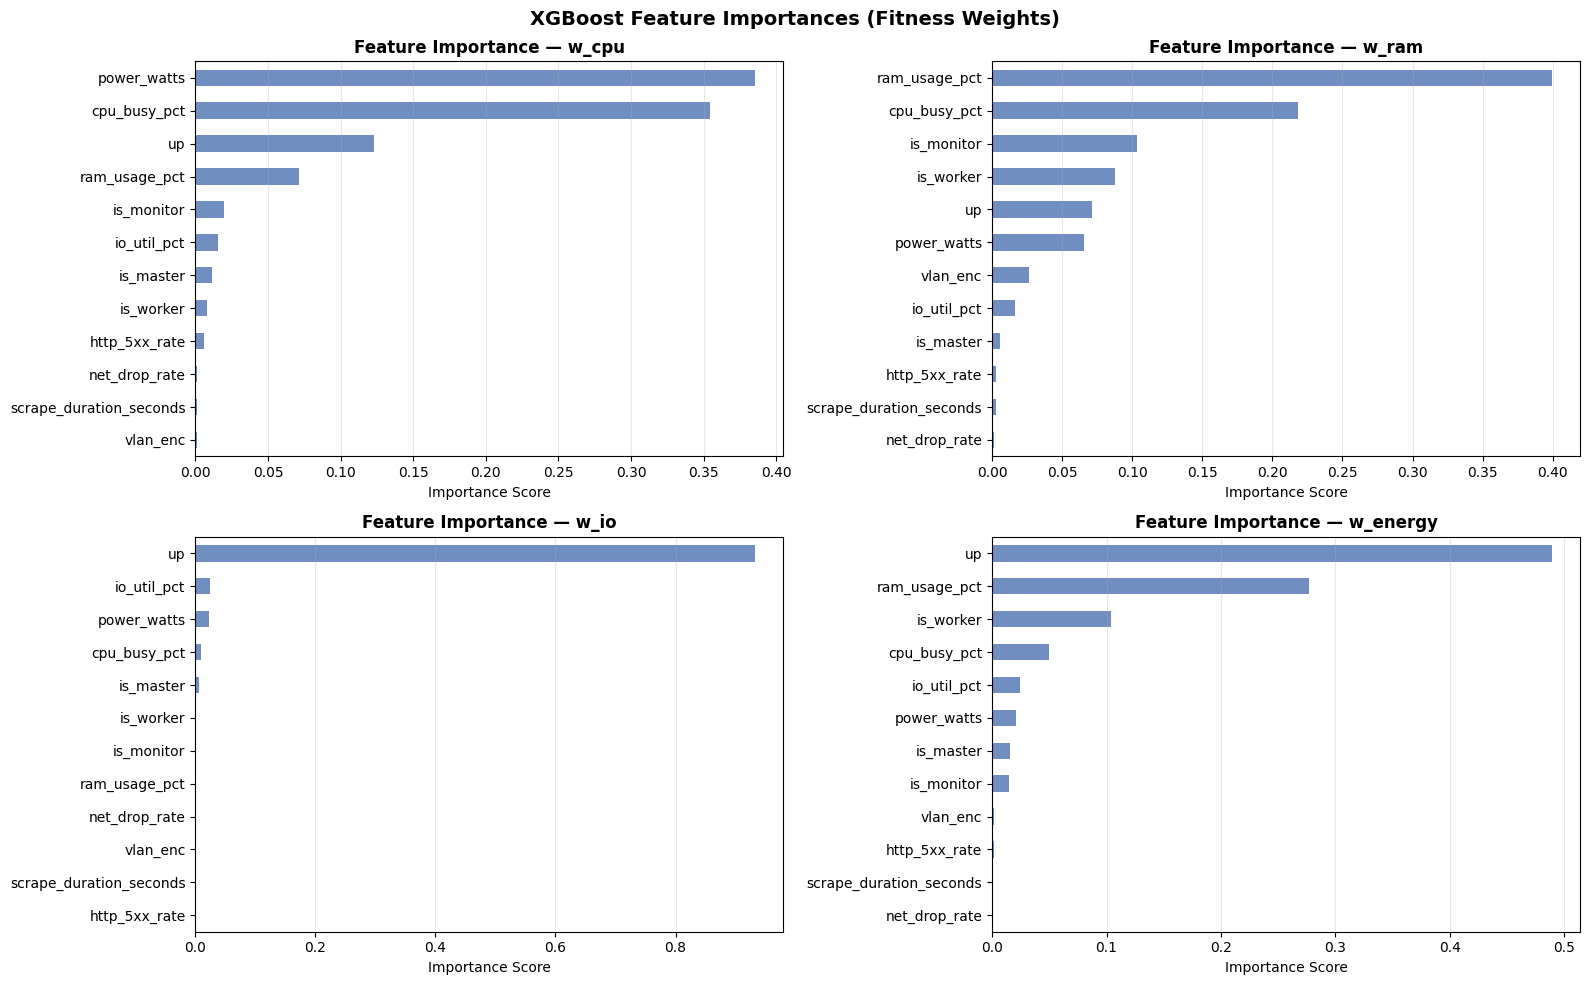

In [ ]:
# Feature importances for the 4 weight models
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, target in enumerate(TARGET_WEIGHTS):
    importances = pd.Series(
        models[target].feature_importances_,
        index=FEATURE_COLS
    ).sort_values(ascending=True)

    importances.plot(kind='barh', ax=axes[i], color='#4C72B0', alpha=0.8)
    axes[i].set_title(f'Feature Importance — {target}', fontweight='bold')
    axes[i].set_xlabel('Importance Score')
    axes[i].grid(axis='x', alpha=0.3)

plt.suptitle('XGBoost Feature Importances (Fitness Weights)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./models/feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Incremental Learning

XGBoost supports **warm-start incremental training** via the `xgb_model=` parameter of `xgb.train()`.  
This **appends new trees** on top of the existing booster — old knowledge is preserved.

```
Existing model (300 trees)  +  New 5-min batch  →  Updated model (320 trees)
```

This function is called by `main.py` every 5 minutes after collecting fresh metrics.

In [ ]:
def engineer_features(df_raw: pd.DataFrame, vlan_enc: LabelEncoder) -> pd.DataFrame:
    """
    Re-usable feature engineering pipeline.
    Input  : raw metrics DataFrame (same schema as 1_influxdb_raw_metrics.csv)
    Output : DataFrame with FEATURE_COLS ready for XGBoost
    """
    df = df_raw.sort_values(['instance', '_time']).reset_index(drop=True).copy()

    df['ram_usage_pct']  = (1 - df['node_memory_MemAvailable_bytes'] / df['node_memory_MemTotal_bytes']) * 100

    cpu_idle_d           = df.groupby('instance')['node_cpu_seconds_total_idle'].diff().fillna(0).clip(lower=0)
    df['cpu_busy_pct']   = (1 - (cpu_idle_d / SCRAPE_INTERVAL).clip(0, 1)) * 100

    io_d                 = df.groupby('instance')['node_disk_io_time_seconds_total'].diff().fillna(0).clip(lower=0)
    df['io_util_pct']    = (io_d / SCRAPE_INTERVAL * 100).clip(0, 100)

    http_all_d           = df.groupby('instance')['http_requests_total_all'].diff().fillna(0).clip(lower=1)
    http_5xx_d           = df.groupby('instance')['http_requests_total_5xx'].diff().fillna(0).clip(lower=0)
    df['http_5xx_rate']  = (http_5xx_d / http_all_d).clip(0, 1)

    pkt_d                = df.groupby('instance')['node_network_receive_packets_total'].diff().fillna(0).clip(lower=1)
    drop_d               = df.groupby('instance')['node_network_receive_drop_total'].diff().fillna(0).clip(lower=0)
    df['net_drop_rate']  = (drop_d / pkt_d).clip(0, 1)

    df['power_watts']    = df['scaph_vm_power_microwatts'] / 1_000_000
    df['is_worker']      = df['vm_name'].str.contains('worker', case=False).astype(int)
    df['is_master']      = df['vm_name'].str.contains('master', case=False).astype(int)
    df['is_monitor']     = df['vm_name'].str.contains('monitoring|influx|snmp', case=False, regex=True).astype(int)

    # Handle unseen VLAN labels gracefully
    known_vlans = set(vlan_enc.classes_)
    df['vlan_safe'] = df['vlan'].where(df['vlan'].isin(known_vlans), other=vlan_enc.classes_[0])
    df['vlan_enc']  = vlan_enc.transform(df['vlan_safe'])

    return df

print("engineer_features() defined ✓")

engineer_features() defined ✓


In [ ]:
def incremental_update(
    new_metrics_csv: str,
    new_logs_csv: str,
    n_new_trees: int = 20,
    models_dir: str = MODELS_DIR,
) -> dict:
    """
    Add `n_new_trees` boosting rounds to each model using a fresh data batch.
    Called every 5 minutes from main.py.

    Parameters
    ----------
    new_metrics_csv : path to new 1_influxdb_raw_metrics.csv batch
    new_logs_csv    : path to new 2_cluster_manager_logs.csv batch
    n_new_trees     : number of new trees to add per model (default 20)
    models_dir      : directory where .ubj files are stored

    Returns
    -------
    dict with MAE improvement per target
    """
    # 1. Load and engineer new batch
    df_m_raw = pd.read_csv(new_metrics_csv)
    df_l_raw = pd.read_csv(new_logs_csv)

    df_m = engineer_features(df_m_raw, vlan_encoder)
    df_new = pd.merge(df_m, df_l_raw, on=['_time', 'instance', 'vm_name'], how='inner')
    df_new = df_new[FEATURE_COLS + ALL_TARGETS].dropna()

    if len(df_new) < 10:
        print("⚠ Not enough new samples for update (need ≥10).")
        return {}

    X_new = df_new[FEATURE_COLS]
    y_new = df_new[ALL_TARGETS]

    update_report = {}

    for target in ALL_TARGETS:
        # 2. Load existing booster from disk
        existing_booster = xgb.Booster()
        existing_booster.load_model(f'{models_dir}/{target}.ubj')

        # MAE before update
        d_new = xgb.DMatrix(X_new, label=y_new[target], feature_names=FEATURE_COLS)
        preds_before = existing_booster.predict(d_new)
        mae_before   = mean_absolute_error(y_new[target], preds_before)

        # 3. Key: xgb_model=existing_booster  →  APPENDS new trees on top
        params = {
            'max_depth'        : 6,
            'learning_rate'    : 0.05,
            'subsample'        : 0.8,
            'colsample_bytree' : 0.8,
            'min_child_weight' : 3,
            'tree_method'      : 'hist',
            'objective'        : 'reg:squarederror',
            'eval_metric'      : 'mae',
            'seed'             : 42,
        }
        updated_booster = xgb.train(
            params,
            d_new,
            num_boost_round = n_new_trees,
            xgb_model       = existing_booster,   # ← incremental learning here
            verbose_eval    = False,
        )

        # MAE after update
        preds_after = updated_booster.predict(d_new)
        mae_after   = mean_absolute_error(y_new[target], preds_after)

        # 4. Save updated model (overwrites previous)
        updated_booster.save_model(f'{models_dir}/{target}.ubj')

        update_report[target] = {
            'mae_before': round(mae_before, 5),
            'mae_after' : round(mae_after,  5),
            'delta'     : round(mae_after - mae_before, 5),
        }
        improvement = '↓' if mae_after < mae_before else '↑'
        print(f"  [{target:15s}]  MAE {mae_before:.5f} → {mae_after:.5f}  {improvement}")

    print(f"\n✓  Incremental update complete (+{n_new_trees} trees per model)")
    return update_report

print("incremental_update() defined ✓")

incremental_update() defined ✓


In [ ]:
# ── Demo: simulate an incremental update using the test split ─────────────────
# In production, main.py will pass fresh CSV files from the last 5-minute window

# Save test data as "new batch" for demonstration
demo_metrics_path = f'{DATA_DIR}/demo_new_metrics.csv'
demo_logs_path    = f'{DATA_DIR}/demo_new_logs.csv'

# Reconstruct raw-looking test rows to pass through engineer_features()
# (In real usage, main.py queries InfluxDB and writes fresh CSVs)
demo_rows = df_merged.loc[X_test.index].copy()
demo_rows[df_metrics.columns.tolist()].to_csv(demo_metrics_path, index=False)
demo_rows[df_logs.columns.tolist()].to_csv(demo_logs_path, index=False)

print("Running incremental update demo on test batch...")
report = incremental_update(demo_metrics_path, demo_logs_path, n_new_trees=20)

Running incremental update demo on test batch...
  [w_cpu          ]  MAE 0.01027 → 0.00457  ↓
  [w_ram          ]  MAE 0.01107 → 0.00516  ↓
  [w_io           ]  MAE 0.01124 → 0.00642  ↓
  [w_energy       ]  MAE 0.00496 → 0.00291  ↓
  [thresh_cpu     ]  MAE 0.61057 → 0.24329  ↓
  [thresh_ram     ]  MAE 0.02362 → 0.01619  ↓
  [thresh_http    ]  MAE 0.28735 → 0.29399  ↑

✓  Incremental update complete (+20 trees per model)


## 10. Prediction Function

This function is imported directly in `main.py` to serve the `/predict-config` endpoint.

In [ ]:
def load_models(models_dir: str = MODELS_DIR) -> dict[str, xgb.Booster]:
    """
    Load all 7 trained boosters from disk.
    Called once at startup in main.py lifespan().
    """
    loaded = {}
    for target in ALL_TARGETS:
        b = xgb.Booster()
        b.load_model(f'{models_dir}/{target}.ubj')
        loaded[target] = b
    print(f"Loaded {len(loaded)} models from '{models_dir}'")
    return loaded


def predict_config(current_metrics: dict, boosters: dict) -> dict:
    """
    Predict optimal weights and thresholds for one VM snapshot.

    Parameters
    ----------
    current_metrics : dict with keys matching FEATURE_COLS
                      (e.g. from Prometheus instant query)
    boosters        : dict[target_name → xgb.Booster], from load_models()

    Returns
    -------
    dict with predicted and post-processed weights + thresholds
    """
    X_input = xgb.DMatrix(
        pd.DataFrame([current_metrics])[FEATURE_COLS],
        feature_names=FEATURE_COLS
    )

    raw = {target: float(boosters[target].predict(X_input)[0]) for target in ALL_TARGETS}

    # ── Post-processing 1: Normalise weights to sum exactly to 1.0 ────────────
    w_sum = sum(max(0.0, raw[t]) for t in TARGET_WEIGHTS)
    if w_sum > 0:
        for t in TARGET_WEIGHTS:
            raw[t] = max(0.0, raw[t]) / w_sum
    else:
        # Fallback to equal weights if model outputs negatives
        for t in TARGET_WEIGHTS:
            raw[t] = 0.25

    # ── Post-processing 2: Clamp thresholds to safe operating ranges ──────────
    raw['thresh_cpu']  = float(np.clip(raw['thresh_cpu'],  50.0, 95.0))
    raw['thresh_ram']  = float(np.clip(raw['thresh_ram'],  55.0, 95.0))
    raw['thresh_http'] = float(np.clip(raw['thresh_http'],  0.1,  5.0))

    return raw


# ── Smoke test ─────────────────────────────────────────────────────────────────
boosters = load_models()

sample_input = {
    'up'                      : 1.0,
    'scrape_duration_seconds' : 0.12,
    'cpu_busy_pct'            : 78.5,
    'ram_usage_pct'           : 65.3,
    'io_util_pct'             : 12.0,
    'http_5xx_rate'           : 0.03,
    'net_drop_rate'           : 0.001,
    'power_watts'             : 95.0,
    'is_worker'               : 1,
    'is_master'               : 0,
    'is_monitor'              : 0,
    'vlan_enc'                : 1,
}

result = predict_config(sample_input, boosters)
print("\nSample prediction:")
for k, v in result.items():
    print(f"  {k:15s} = {v:.4f}")
print(f"\n  Weight sum check: {sum(result[t] for t in TARGET_WEIGHTS):.6f}  (should be 1.0)")

Loaded 7 models from './models'

Sample prediction:
  w_cpu           = 0.3041
  w_ram           = 0.2588
  w_io            = 0.0313
  w_energy        = 0.4058
  thresh_cpu      = 64.7984
  thresh_ram      = 78.5137
  thresh_http     = 0.6033

  Weight sum check: 1.000000  (should be 1.0)


## 11. Integration with main.py

Copy this code into your `main.py` to add the `/predict-config` endpoint  
and the 5-minute scheduled incremental update job.

In [ ]:
MAIN_PY_SNIPPET = '''
# ─────────────────────────────────────────────────────────────────────────────
#  XGBoost Adaptive Config  — add these blocks to main.py
# ─────────────────────────────────────────────────────────────────────────────

# ── 1. Imports (add to top of main.py) ────────────────────────────────────────
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error  # only needed if logging MAE

MODELS_DIR   = os.getenv("MODELS_DIR",   "./models")
DATA_BUFFER  = os.getenv("DATA_BUFFER",  "./data/live_buffer")  # rolling CSVs
os.makedirs(DATA_BUFFER, exist_ok=True)

FEATURE_COLS   = [
    "up", "scrape_duration_seconds", "cpu_busy_pct", "ram_usage_pct",
    "io_util_pct", "http_5xx_rate", "net_drop_rate", "power_watts",
    "is_worker", "is_master", "is_monitor", "vlan_enc",
]
TARGET_WEIGHTS = ["w_cpu", "w_ram", "w_io", "w_energy"]
TARGET_THRESH  = ["thresh_cpu", "thresh_ram", "thresh_http"]
ALL_TARGETS    = TARGET_WEIGHTS + TARGET_THRESH

# ── 2. Global booster dict (loaded once at startup) ───────────────────────────
_ml_boosters: dict[str, xgb.Booster] = {}


def _load_ml_models():
    global _ml_boosters
    for target in ALL_TARGETS:
        b = xgb.Booster()
        b.load_model(f"{MODELS_DIR}/{target}.ubj")
        _ml_boosters[target] = b
    logger.info(f"ML: loaded {len(_ml_boosters)} XGBoost models")


# ── 3. Call _load_ml_models() inside lifespan() ───────────────────────────────
# @asynccontextmanager
# async def lifespan(app: FastAPI):
#     ...existing code...
#     _load_ml_models()                          # ← add this line
#     scheduler.add_job(ml_incremental_update_job, "interval", minutes=5, max_instances=1)
#     ...


# ── 4. Predict config endpoint ────────────────────────────────────────────────
@app.get("/predict-config/{instance_id}")
async def predict_config_endpoint(instance_id: str):
    """
    Returns predicted optimal weights and thresholds for one VM instance.
    Reads current metrics from cluster_state (populated by poll_cluster).
    """
    if not _ml_boosters:
        raise HTTPException(503, "ML models not loaded yet")

    # Fetch live metrics from cluster_state
    async with _state_lock:
        vm = cluster_state["vms"].get(instance_id) or cluster_state["lxc"].get(instance_id)
    if not vm:
        raise HTTPException(404, f"Instance {instance_id} not found in cluster state")

    # Build feature vector from live state
    features = {
        "up"                      : 1.0 if vm.get("status") == "running" else 0.0,
        "scrape_duration_seconds" : vm.get("scrape_duration", 0.1),
        "cpu_busy_pct"            : vm.get("cpu", 0.0) * 100,
        "ram_usage_pct"           : (1 - vm.get("mem", 0) / max(vm.get("maxmem", 1), 1)) * 100,
        "io_util_pct"             : vm.get("disk", 0.0) * 100,
        "http_5xx_rate"           : vm.get("http_5xx_rate", 0.0),
        "net_drop_rate"           : vm.get("net_drop_rate", 0.0),
        "power_watts"             : vm.get("power_watts", 50.0),
        "is_worker"               : int("worker" in instance_id.lower()),
        "is_master"               : int("master" in instance_id.lower()),
        "is_monitor"              : int(any(r in instance_id.lower() for r in ["monitor","influx","snmp"])),
        "vlan_enc"                : 1,  # or encode from vm.get("vlan")
    }

    X_input = xgb.DMatrix(
        pd.DataFrame([features])[FEATURE_COLS],
        feature_names=FEATURE_COLS
    )

    raw = {t: float(_ml_boosters[t].predict(X_input)[0]) for t in ALL_TARGETS}

    # Normalise weights to sum to 1
    w_sum = sum(max(0.0, raw[t]) for t in TARGET_WEIGHTS)
    for t in TARGET_WEIGHTS:
        raw[t] = max(0.0, raw[t]) / w_sum if w_sum > 0 else 0.25

    # Clamp thresholds
    raw["thresh_cpu"]  = float(np.clip(raw["thresh_cpu"],  50.0, 95.0))
    raw["thresh_ram"]  = float(np.clip(raw["thresh_ram"],  55.0, 95.0))
    raw["thresh_http"] = float(np.clip(raw["thresh_http"],  0.1,  5.0))

    return {"instance": instance_id, "config": raw}


# ── 5. Scheduled incremental update job ──────────────────────────────────────
async def ml_incremental_update_job():
    """
    Runs every 5 minutes. Queries InfluxDB for the last 5-min window,
    writes CSVs to DATA_BUFFER, then calls incremental_update().
    After updating, reloads boosters into _ml_boosters.
    """
    logger.info("ML: starting incremental update...")
    try:
        # TODO: replace with actual InfluxDB / Prometheus query
        # For now this is a placeholder that copies the buffer CSVs
        new_metrics = f"{DATA_BUFFER}/metrics_latest.csv"
        new_logs    = f"{DATA_BUFFER}/logs_latest.csv"

        if not (os.path.exists(new_metrics) and os.path.exists(new_logs)):
            logger.warning("ML: buffer CSVs not found, skipping update")
            return

        await asyncio.to_thread(
            incremental_update, new_metrics, new_logs, 20, MODELS_DIR
        )
        # Reload boosters so predictions immediately use new models
        await asyncio.to_thread(_load_ml_models)
        logger.info("ML: incremental update complete, models reloaded")

    except Exception as exc:
        logger.error(f"ML: incremental update failed — {exc}")
'''

print(MAIN_PY_SNIPPET)


# ─────────────────────────────────────────────────────────────────────────────
#  XGBoost Adaptive Config  — add these blocks to main.py
# ─────────────────────────────────────────────────────────────────────────────

# ── 1. Imports (add to top of main.py) ────────────────────────────────────────
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error  # only needed if logging MAE

MODELS_DIR   = os.getenv("MODELS_DIR",   "./models")
DATA_BUFFER  = os.getenv("DATA_BUFFER",  "./data/live_buffer")  # rolling CSVs
os.makedirs(DATA_BUFFER, exist_ok=True)

FEATURE_COLS   = [
    "up", "scrape_duration_seconds", "cpu_busy_pct", "ram_usage_pct",
    "io_util_pct", "http_5xx_rate", "net_drop_rate", "power_watts",
    "is_worker", "is_master", "is_monitor", "vlan_enc",
]
TARGET_WEIGHTS = ["w_cpu", "w_ram", "w_io", "w_energy"]
TARGET_THRESH  = ["thresh_cpu", "thresh_ram", "thresh_http"]
ALL_TARGETS    = TARGET_WEIGHTS + TARGET_THRESH

# ── 

## 12. Save Artefacts for main.py

In [ ]:
import json

# Save VLAN encoder classes so main.py can rebuild it
joblib.dump(vlan_encoder, f'{MODELS_DIR}/vlan_encoder.joblib')

# Save feature column order (critical — must match main.py exactly)
with open(f'{MODELS_DIR}/feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)

# Save evaluation results
pd.DataFrame(results).T.to_csv(f'{MODELS_DIR}/evaluation_results.csv')

print("Saved:")
for fname in os.listdir(MODELS_DIR):
    fpath = os.path.join(MODELS_DIR, fname)
    print(f"  {fname:40s}  {os.path.getsize(fpath) / 1024:.1f} KB")

Saved:
  thresh_ram.ubj                            1456.8 KB
  feature_importances.png                   160.6 KB
  w_cpu.ubj                                 1435.0 KB
  target_distributions.png                  142.9 KB
  vlan_encoder.joblib                       0.5 KB
  thresh_http.ubj                           1414.8 KB
  w_io.ubj                                  1302.7 KB
  thresh_cpu.ubj                            1333.8 KB
  w_ram.ubj                                 1468.3 KB
  feature_cols.json                         0.2 KB
  evaluation_results.csv                    0.3 KB
  w_energy.ubj                              1408.8 KB
